# PG CON DATOS DE EXCEL

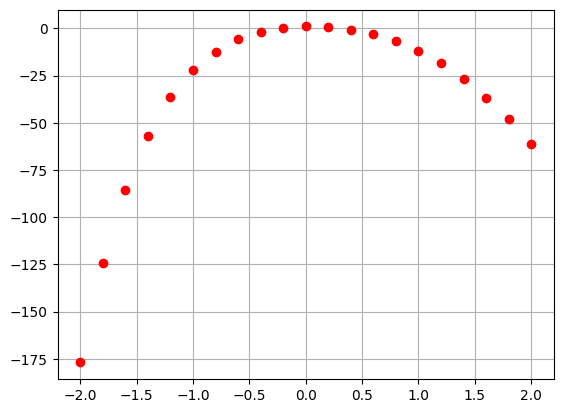

In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

datos = pd.read_excel('data.xlsx')
x = datos['x']
y = datos['y']
plt.plot(x,y,'ro')
plt.grid()

In [8]:
#Importamos Librerias
import operator 
import random
import math
import numpy as np 
from deap import base, creator, gp, tools, algorithms

In [9]:
#Creamos el conjunto de primitivas
pset = gp.PrimitiveSet ("MAIN",1) # Es el número de argumentos (x)
pset.addPrimitive(operator.add, 2) # suma
pset.addPrimitive(operator.sub, 2) # resta
pset.addPrimitive(operator.mul, 2)# multiplicación
pset.addPrimitive(operator.neg, 1)# negación (cambio de signo)
pset.addPrimitive(math.sin, 1)# seno
pset.addPrimitive(math.cos, 1)# coseno
pset.addEphemeralConstant ("rand101", lambda: random.uniform(-1, 1)) # constante aleatoria


c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\deap\gp.py:257: RuntimeWarning: Ephemeral rand101 function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


In [10]:
#RENOMBRAMOS EL ARGUMENTO
pset.renameArguments(ARG0='x')

#DEFINIR EL TIPO DE FITNESS (minimizar el error)
creator.create('FitnessMin',base.Fitness, weights = (-1.0,))
creator.create('Individuo',gp.PrimitiveTree, fitness = creator.FitnessMin)

#Funciones para inicializar individuos y población
toolbox = base.Toolbox()

toolbox.register('expr', gp.genHalfAndHalf, pset = pset, min_ = 1, max_ = 2)
toolbox.register('individuo', tools.initIterate, creator.Individuo, toolbox.expr)
toolbox.register('population', tools.initRepeat,list,toolbox.individuo)

# FUNCION PARA COMPILAR LOS ÁRBOLES EN FUNCIONES EJECUTABLES
toolbox.register("compile", gp.compile, pset=pset)

# FUNCIÓN DE EVALUACIÓN (error cuadrático medio)
# Puntos de datos
data_points = x
valores_objetivo = y


def evaluar(individual):
    # Convertir el individuo en una función
    func = toolbox.compile(expr=individual)
    
    # Calcular los errores cuadráticos
    errores_cuad = []
    for x, y in zip(data_points, valores_objetivo):
        error = (func(x) - y)**2
        errores_cuad.append(error)
        
    # Devolver el error cuadrático medio (MSE)
    return math.fsum(errores_cuad) / len(data_points),

#MECANISMOS EVOLUTIVOS
toolbox.register('evaluate', evaluar)
toolbox.register('select',tools.selTournament, tournsize = 3)
toolbox.register('mate',gp.cxOnePoint)
toolbox.register('expr_mut',gp.genFull,min_=0,max_=2)
toolbox.register('mutate',gp.mutUniform,expr=toolbox.expr_mut,pset=pset)

#SE LIMITA LA PROFUNDIDAD DE LOS INDIVIDUOS
toolbox.decorate('mate',gp.staticLimit(key=lambda ind: ind.height,max_value=17))
toolbox.decorate('mutate',gp.staticLimit(key=lambda ind: ind.height,max_value=17))

c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individuo' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:
# ALGORITMO EVOLUTIVO
# Crear población inicial
Poblacion = toolbox.population(n=100)
hof = tools.HallOfFame(1)

# Estadísticas de la población
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

# Algoritmo evolutivo simple
algorithms.eaSimple(Poblacion, toolbox, 0.5, 0.05, 100, stats=stats, halloffame=hof, verbose=True)

# Mostrar el mejor individuo (la mejor expresión)
print("\nMejor individuo:")
print(hof[0])
print()

# PARA VISUALIZAR EL MEJOR INDIVIDUO

import sympy
x = sympy.Symbol("x")

# Mapeo de nombres usados en DEAP a funciones de sympy
replacements = {
    "add": lambda a, b: a + b,
    "sub": lambda a, b: a - b,
    "mul": lambda a, b: a * b,
    "neg": lambda a: -a,
    "sin": sympy.sin,
    "cos": sympy.cos,
}

expr_str = str(hof[0]) # expresión en string que da DEAP
expr_sympy = sympy.sympify(expr_str, locals=replacements)
print("\nExpresión simplificada:\n", sympy.simplify(expr_sympy))

#Convertir el mejor individuo en una funcion y mostrar cómo ajusta los pts
best_func = toolbox.compile(expr=hof[0])
print()

#Comparar con los valores originales
for x,y in zip(data_points,valores_objetivo):
    print(f'x = {x:.2f},predicho = {best_func(x):.2f},real = {y:.2f}')

gen	nevals	avg    	std    	min    	max    
0  	100   	3259.15	67.6087	3101.22	3495.82
1  	50    	3210.78	50.7015	3040.89	3336.23
2  	45    	3183.95	58.1186	3034.97	3395.4 
3  	57    	3159.66	65.0758	3017.34	3447.7 
4  	53    	3132.31	66.0008	3008.89	3444.14
5  	51    	3101.67	72.8757	2850.85	3311.54
6  	57    	3062.94	110.008	2820.26	3444.14
7  	54    	3035.8 	153.993	2430.69	3475.38
8  	61    	2975.64	169.917	2430.69	3444.14
9  	44    	2897.48	208.078	2430.69	4006.13
10 	51    	2885.21	205.981	2493.92	3412.86
11 	55    	2788.81	228.191	2426.21	3840.63
12 	56    	2813.48	574.292	1243.82	6165.3 
13 	54    	2691.33	663.061	1243.82	6722.89
14 	47    	2403.92	564.974	1243.82	6182.64
15 	52    	2374.45	1930.47	648.557	19779.9
16 	46    	1944.14	865.312	316.03 	6302.82
17 	62    	2760.78	8896.8 	316.03 	88636.9
18 	56    	3204.7 	18956.7	198.639	191428 
19 	52    	1230.9 	4123.03	119.602	41554.6
20 	47    	657.46 	755.824	139.395	5823.57
21 	48    	4526.66	33264.6	82.875 	332043 
22 	40    	

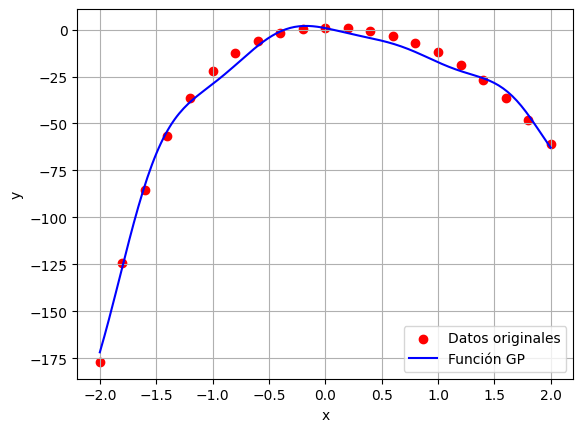

In [ ]:

best_func = toolbox.compile(expr=hof[0])
x_line = np.linspace(min(data_points), max(data_points), 200)
y_line = [best_func(x) for x in x_line]
plt.scatter(data_points, valores_objetivo, color="red", label="Datos originales")
plt.plot(x_line, y_line, color="blue", label="Función GP")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()